# Logical Fallacy Detection
**Dataset:** CoCoLoFa (Comments with Common Logical Fallacies)
https://github.com/Crowd-AI-Lab/cocolofa

**Pipeline:** Teks Mentah → Cleaning → Tokenisasi → Lemmatization → Representasi Teks (TF-IDF & Word2Vec)

## 0. Import Libraries

In [ ]:
import json
import re
import numpy as np
import pandas as pd

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

All imports successful!


## 1. Load Dataset

In [2]:
# Load the train.json dataset
with open('train.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# Extract all comments from every news article
records = []
for article in raw_data:
    for comment in article['comments']:
        records.append({
            'comment_id': comment['id'],
            'news_id': comment['news_id'],
            'fallacy': comment['fallacy'],
            'comment': comment['comment']
        })

df = pd.DataFrame(records)

print(f"Total komentar: {len(df)}")
print(f"\nDistribusi label fallacy:")
print(df['fallacy'].value_counts())
print(f"\n--- Sample Data (Teks Mentah) ---")
df.head(10)

Total komentar: 5370

Distribusi label fallacy:
fallacy
none                        2202
slippery slope               431
appeal to worse problems     421
appeal to nature             412
appeal to tradition          401
false dilemma                391
appeal to majority           383
hasty generalization         379
appeal to authority          350
Name: count, dtype: int64

--- Sample Data (Teks Mentah) ---


,comment_id,news_id,fallacy,comment
0,5584,262,none,Lack of transparency in government isn't unexp...
1,5582,262,appeal to authority,While the issues discussed here should be addr...
2,5583,262,none,The excuse that Brazilian municipalities do no...
3,6183,262,none,This is what's to be expected of developing an...
4,6182,262,appeal to tradition,"Sad to say, I have to agree with you. Rulers c..."
5,6184,262,none,Why doesn't the Brazilian federal government s...
6,6782,262,appeal to worse problems,At least they have a set up for it. In some co...
7,6783,262,hasty generalization,If these people can't even manage doing someth...
8,6784,262,appeal to tradition,I completely agree with you! There have alway...
9,10082,262,slippery slope,The argument that people should have access to...


## 2. Text Cleaning

In [3]:
def clean_text(text):
    """Membersihkan teks mentah."""
    text = text.lower()                                    # lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)           # hapus URL
    text = re.sub(r'<[^>]+>', '', text)                    # hapus HTML tags
    text = re.sub(r'@\w+', '', text)                       # hapus mentions
    text = re.sub(r'#\w+', '', text)                       # hapus hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)                # hapus angka & special chars
    text = re.sub(r'\s+', ' ', text).strip()               # hapus spasi berlebih
    return text

df['cleaned'] = df['comment'].apply(clean_text)

print("--- Contoh Sebelum & Sesudah Cleaning ---")
for i in range(3):
    print(f"\n[BEFORE]: {df['comment'].iloc[i][:120]}...")
    print(f"[AFTER ]: {df['cleaned'].iloc[i][:120]}...")

--- Contoh Sebelum & Sesudah Cleaning ---

[BEFORE]: Lack of transparency in government isn't unexpected.  No one likes to be under scrutiny,  especially not those with powe...
[AFTER ]: lack of transparency in government isnt unexpected no one likes to be under scrutiny especially not those with power tra...

[BEFORE]: While the issues discussed here should be addressed, there need to be priorities. The authorities of the country probabl...
[AFTER ]: while the issues discussed here should be addressed there need to be priorities the authorities of the country probably ...

[BEFORE]: The excuse that Brazilian municipalities do not have the funds to handle the public service requests does not hold water...
[AFTER ]: the excuse that brazilian municipalities do not have the funds to handle the public service requests does not hold water...


## 3. Tokenisasi

In [4]:
df['tokens'] = df['cleaned'].apply(word_tokenize)

print("--- Contoh Hasil Tokenisasi ---")
for i in range(3):
    print(f"\n[CLEANED ]: {df['cleaned'].iloc[i][:100]}...")
    print(f"[TOKENS  ]: {df['tokens'].iloc[i][:15]}...")
    print(f"Jumlah token: {len(df['tokens'].iloc[i])}")

--- Contoh Hasil Tokenisasi ---

[CLEANED ]: lack of transparency in government isnt unexpected no one likes to be under scrutiny especially not ...
[TOKENS  ]: ['lack', 'of', 'transparency', 'in', 'government', 'isnt', 'unexpected', 'no', 'one', 'likes', 'to', 'be', 'under', 'scrutiny', 'especially']...
Jumlah token: 64

[CLEANED ]: while the issues discussed here should be addressed there need to be priorities the authorities of t...
[TOKENS  ]: ['while', 'the', 'issues', 'discussed', 'here', 'should', 'be', 'addressed', 'there', 'need', 'to', 'be', 'priorities', 'the', 'authorities']...
Jumlah token: 55

[CLEANED ]: the excuse that brazilian municipalities do not have the funds to handle the public service requests...
[TOKENS  ]: ['the', 'excuse', 'that', 'brazilian', 'municipalities', 'do', 'not', 'have', 'the', 'funds', 'to', 'handle', 'the', 'public', 'service']...
Jumlah token: 93


## 4. Stopword Removal & Lemmatization

> Dipilih **lemmatization** daripada stemming karena menghasilkan kata dasar yang valid secara bahasa, lebih cocok untuk tugas deteksi fallacy yang membutuhkan pemahaman makna.

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    """Hapus stopwords dan lemmatize setiap token."""
    return [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2  # juga hapus token terlalu pendek
    ]

df['lemmatized'] = df['tokens'].apply(lemmatize_tokens)

# Gabungkan kembali menjadi string untuk keperluan TF-IDF
df['processed_text'] = df['lemmatized'].apply(lambda x: ' '.join(x))

print("--- Contoh Hasil Lemmatization ---")
for i in range(3):
    print(f"\n[TOKENS     ]: {df['tokens'].iloc[i][:12]}...")
    print(f"[LEMMATIZED ]: {df['lemmatized'].iloc[i][:12]}...")
    print(f"Jumlah token sebelum: {len(df['tokens'].iloc[i])} → sesudah: {len(df['lemmatized'].iloc[i])}")

--- Contoh Hasil Lemmatization ---

[TOKENS     ]: ['lack', 'of', 'transparency', 'in', 'government', 'isnt', 'unexpected', 'no', 'one', 'likes', 'to', 'be']...
[LEMMATIZED ]: ['lack', 'transparency', 'government', 'isnt', 'unexpected', 'one', 'like', 'scrutiny', 'especially', 'power', 'transparency', 'law']...
Jumlah token sebelum: 64 → sesudah: 31

[TOKENS     ]: ['while', 'the', 'issues', 'discussed', 'here', 'should', 'be', 'addressed', 'there', 'need', 'to', 'be']...
[LEMMATIZED ]: ['issue', 'discussed', 'addressed', 'need', 'priority', 'authority', 'country', 'probably', 'know', 'whats', 'important', 'deal']...
Jumlah token sebelum: 55 → sesudah: 29

[TOKENS     ]: ['the', 'excuse', 'that', 'brazilian', 'municipalities', 'do', 'not', 'have', 'the', 'funds', 'to', 'handle']...
[LEMMATIZED ]: ['excuse', 'brazilian', 'municipality', 'fund', 'handle', 'public', 'service', 'request', 'hold', 'water', 'evident', 'fact']...
Jumlah token sebelum: 93 → sesudah: 48


## 5. Representasi Teks

### a. TF-IDF (Term Frequency–Inverse Document Frequency) 

**TF-IDF** mengukur seberapa penting suatu kata dalam sebuah dokumen relatif terhadap seluruh korpus.
- Cocok sebagai baseline karena menangkap pola kata kunci yang sering muncul di tiap jenis fallacy.
- Menghasilkan sparse matrix berdimensi tinggi.

In [6]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} dokumen, {tfidf_matrix.shape[1]} fitur")

# Tampilkan top fitur TF-IDF untuk beberapa sampel
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nContoh 20 fitur (kata/bigram): {list(feature_names[:20])}")

# Konversi ke DataFrame untuk preview
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names
)
print(f"\n--- Preview TF-IDF Matrix (5 dokumen pertama, 10 fitur pertama) ---")
tfidf_df.iloc[:5, :10]

TF-IDF Matrix Shape: (5370, 5000)
  → 5370 dokumen, 5000 fitur

Contoh 20 fitur (kata/bigram): ['abandon', 'abandoned', 'ability', 'able', 'able access', 'able express', 'able get', 'able speak', 'absolute', 'absolutely', 'absurd', 'abuse', 'abuse power', 'abused', 'academic', 'academic freedom', 'accept', 'acceptable', 'acceptance', 'accepted']

--- Preview TF-IDF Matrix (5 dokumen pertama, 10 fitur pertama) ---


,abandon,abandoned,ability,able,able access,able express,able get,able speak,absolute,absolutely
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### b. Word2Vec
**Word2Vec** mempelajari embedding vektor untuk setiap kata berdasarkan konteks kemunculannya.
- Menangkap hubungan semantik antar kata (misal: "authority" dekat dengan "expert", "tradition" dekat dengan "culture").
- Representasi dokumen diperoleh dengan merata-ratakan vektor semua kata dalam dokumen.
- Menghasilkan dense vector berdimensi tetap untuk setiap dokumen.

In [7]:
# Train Word2Vec pada corpus lemmatized
w2v_model = Word2Vec(
    sentences=df['lemmatized'].tolist(),
    vector_size=100,    # dimensi embedding
    window=5,           # context window
    min_count=2,        # abaikan kata yang muncul < 2 kali
    workers=4,
    epochs=20,
    sg=1                # skip-gram (lebih baik untuk dataset kecil)
)

print(f"Vocabulary size: {len(w2v_model.wv)}")
print(f"Vector dimension: {w2v_model.wv.vector_size}")

# Contoh kata-kata mirip
for word in ['government', 'freedom', 'protest']:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\nKata mirip dengan '{word}':")
        for w, score in similar:
            print(f"  {w}: {score:.4f}")

Vocabulary size: 6642
Vector dimension: 100

Kata mirip dengan 'government':
  fearful: 0.6204
  andor: 0.6189
  voiceless: 0.6168
  overreaching: 0.6155
  seizing: 0.6150

Kata mirip dengan 'freedom':
  expression: 0.6785
  speech: 0.6387
  inviolate: 0.6248
  liberty: 0.6154
  infringed: 0.5982

Kata mirip dengan 'protest':
  peacefully: 0.5566
  demonstration: 0.5349
  eruption: 0.5266
  peaceful: 0.5252
  gezi: 0.5162


In [8]:
def document_vector(tokens, model):
    """Hitung rata-rata Word2Vec vector untuk seluruh token dalam dokumen."""
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vectors, axis=0)

# Buat document vectors untuk semua komentar
w2v_vectors = np.array([
    document_vector(tokens, w2v_model) for tokens in df['lemmatized']
])

w2v_df = pd.DataFrame(
    w2v_vectors,
    columns=[f'w2v_dim_{i}' for i in range(w2v_model.wv.vector_size)]
)

print(f"Word2Vec Document Matrix Shape: {w2v_vectors.shape}")
print(f"  → {w2v_vectors.shape[0]} dokumen, {w2v_vectors.shape[1]} dimensi")
print(f"\n--- Preview Word2Vec Document Vectors (5 dokumen pertama, 10 dimensi pertama) ---")
w2v_df.iloc[:5, :10]

Word2Vec Document Matrix Shape: (5370, 100)
  → 5370 dokumen, 100 dimensi

--- Preview Word2Vec Document Vectors (5 dokumen pertama, 10 dimensi pertama) ---


,w2v_dim_0,w2v_dim_1,w2v_dim_2,w2v_dim_3,w2v_dim_4,w2v_dim_5,w2v_dim_6,w2v_dim_7,w2v_dim_8,w2v_dim_9
0,-0.240442,0.203226,-0.115126,0.025479,0.040393,-0.472543,0.062516,0.351746,-0.083399,-0.173677
1,-0.230614,0.048297,0.042232,-0.084524,0.118773,-0.240947,0.220081,0.243901,-0.052737,-0.194557
2,-0.228519,0.175143,-0.117752,0.027849,0.131943,-0.335909,0.053553,0.390247,-0.154784,-0.118781
3,-0.139892,0.204531,-0.079792,-0.026774,0.028961,-0.329633,0.184882,0.347637,-0.001035,-0.042614
4,-0.283162,0.247074,0.033644,0.028052,-0.018645,-0.234504,0.113144,0.276887,-0.033340,-0.097965


## 6. Label Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['fallacy'])

print(f"Jumlah kelas: {len(label_encoder.classes_)}")
print(f"\nMapping label:")
for i, cls in enumerate(label_encoder.classes_):
    count = (df['label'] == i).sum()
    print(f"  {i} → {cls} ({count} sampel)")

Jumlah kelas: 9

Mapping label:
  0 → appeal to authority (350 sampel)
  1 → appeal to majority (383 sampel)
  2 → appeal to nature (412 sampel)
  3 → appeal to tradition (401 sampel)
  4 → appeal to worse problems (421 sampel)
  5 → false dilemma (391 sampel)
  6 → hasty generalization (379 sampel)
  7 → none (2202 sampel)
  8 → slippery slope (431 sampel)


## 7. Model Training

Melatih beberapa model klasifikasi pada kedua representasi fitur (TF-IDF dan Word2Vec):
- **Logistic Regression** — baseline linear yang kuat
- **Linear SVC** — SVM linear, efektif untuk teks berdimensi tinggi
- **Random Forest** — ensemble berbasis decision tree
- **Gradient Boosting** — ensemble boosting untuk performa optimal
- **K-Nearest Neighbors** — instance-based learning

> Semua model menggunakan `class_weight='balanced'` (jika tersedia) untuk menangani ketidakseimbangan kelas.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

y_train = df['label'].values

# ============================================================
# Train on TF-IDF features
# ============================================================
print("=" * 65)
print("  Training models on TF-IDF features")
print("=" * 65)

tfidf_models = {}
for name, model in [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
    ('Linear SVC', LinearSVC(max_iter=2000, random_state=42, class_weight='balanced')),
    ('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=7)),
]:
    model.fit(tfidf_matrix, y_train)
    tfidf_models[name] = model
    train_pred = model.predict(tfidf_matrix)
    train_acc = accuracy_score(y_train, train_pred)
    train_f1 = f1_score(y_train, train_pred, average='weighted')
    print(f"  {name:25s} → Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")

# ============================================================
# Train on Word2Vec features
# ============================================================
print(f"\n{'=' * 65}")
print("  Training models on Word2Vec features")
print("=" * 65)

w2v_models_dict = {}
for name, model in [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
    ('Linear SVC', LinearSVC(max_iter=2000, random_state=42, class_weight='balanced')),
    ('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=7)),
]:
    model.fit(w2v_vectors, y_train)
    w2v_models_dict[name] = model
    train_pred = model.predict(w2v_vectors)
    train_acc = accuracy_score(y_train, train_pred)
    train_f1 = f1_score(y_train, train_pred, average='weighted')
    print(f"  {name:25s} → Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")

print(f"\n✓ Total models trained: {len(tfidf_models) + len(w2v_models_dict)}")

  Training models on TF-IDF features
  Logistic Regression       → Train Acc: 0.8104 | Train F1: 0.8038
  Linear SVC                → Train Acc: 0.9631 | Train F1: 0.9629
  Random Forest             → Train Acc: 1.0000 | Train F1: 1.0000
  Gradient Boosting         → Train Acc: 0.9177 | Train F1: 0.9133
  K-Nearest Neighbors       → Train Acc: 0.6160 | Train F1: 0.5985

  Training models on Word2Vec features
  Logistic Regression       → Train Acc: 0.5246 | Train F1: 0.4957
  Linear SVC                → Train Acc: 0.5628 | Train F1: 0.5472
  Random Forest             → Train Acc: 1.0000 | Train F1: 1.0000
  Gradient Boosting         → Train Acc: 0.9477 | Train F1: 0.9473
  K-Nearest Neighbors       → Train Acc: 0.6393 | Train F1: 0.6274

✓ Total models trained: 10


## 8. Load & Preprocess Test Data

Memuat `test.json` dan menerapkan pipeline preprocessing yang sama (cleaning → tokenisasi → lemmatization → representasi fitur) agar konsisten dengan data latih.

In [11]:
# Load test dataset
with open('test.json', 'r', encoding='utf-8') as f:
    test_raw = json.load(f)

# Extract comments
test_records = []
for article in test_raw:
    for comment in article['comments']:
        test_records.append({
            'comment_id': comment['id'],
            'news_id': comment['news_id'],
            'fallacy': comment['fallacy'],
            'comment': comment['comment']
        })

df_test = pd.DataFrame(test_records)

print(f"Total komentar test: {len(df_test)}")
print(f"\nDistribusi label test:")
print(df_test['fallacy'].value_counts())

# Apply same preprocessing pipeline
df_test['cleaned'] = df_test['comment'].apply(clean_text)
df_test['tokens'] = df_test['cleaned'].apply(word_tokenize)
df_test['lemmatized'] = df_test['tokens'].apply(lemmatize_tokens)
df_test['processed_text'] = df_test['lemmatized'].apply(lambda x: ' '.join(x))

# Encode labels using the same encoder
df_test['label'] = label_encoder.transform(df_test['fallacy'])

# Transform to feature representations (use fitted vectorizer — NOT fit_transform)
X_test_tfidf = tfidf_vectorizer.transform(df_test['processed_text'])
X_test_w2v = np.array([document_vector(tokens, w2v_model) for tokens in df_test['lemmatized']])
y_test = df_test['label'].values

print(f"\nTest TF-IDF shape: {X_test_tfidf.shape}")
print(f"Test Word2Vec shape: {X_test_w2v.shape}")
print(f"\n--- Sample Preprocessed Test Data ---")
df_test[['comment', 'cleaned', 'processed_text', 'fallacy']].head(5)

Total komentar test: 798

Distribusi label test:
fallacy
none                        317
slippery slope               78
appeal to worse problems     64
hasty generalization         60
appeal to tradition          59
appeal to majority           59
appeal to authority          56
appeal to nature             55
false dilemma                50
Name: count, dtype: int64

Test TF-IDF shape: (798, 5000)
Test Word2Vec shape: (798, 100)

--- Sample Preprocessed Test Data ---


,comment,cleaned,processed_text,fallacy
0,Once you let them dictate rules against fairne...,once you let them dictate rules against fairne...,let dictate rule fairness continue problem get...,slippery slope
1,Why can't the higher ups in journalism circles...,why cant the higher ups in journalism circles ...,cant higher ups journalism circle spain help w...,appeal to authority
2,Hopefully the country of Spain can provide wom...,hopefully the country of spain can provide wom...,hopefully country spain provide woman generali...,appeal to authority
3,I understand why you think having a rule that ...,i understand why you think having a rule that ...,understand think rule believe unfair would tro...,none
4,I am much more likely to trust the people in c...,i am much more likely to trust the people in c...,much likely trust people charge organization w...,appeal to authority


## 9. Evaluation on Test Set

Mengevaluasi semua model pada data test dan membandingkan performa menggunakan metrik:
- **Accuracy** — proporsi prediksi benar
- **Precision / Recall / F1 (weighted)** — mempertimbangkan ketidakseimbangan kelas
- **F1 (macro)** — rata-rata F1 per kelas tanpa bobot (lebih ketat untuk kelas minoritas)

In [12]:
from sklearn.metrics import precision_recall_fscore_support

results = []

# Evaluate TF-IDF models
for name, model in tfidf_models.items():
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    results.append({
        'Model': name, 'Features': 'TF-IDF',
        'Accuracy': acc, 'Precision (weighted)': p,
        'Recall (weighted)': r, 'F1 (weighted)': f1, 'F1 (macro)': f1_macro,
    })

# Evaluate Word2Vec models
for name, model in w2v_models_dict.items():
    y_pred = model.predict(X_test_w2v)
    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    results.append({
        'Model': name, 'Features': 'Word2Vec',
        'Accuracy': acc, 'Precision (weighted)': p,
        'Recall (weighted)': r, 'F1 (weighted)': f1, 'F1 (macro)': f1_macro,
    })

results_df = pd.DataFrame(results).sort_values('F1 (weighted)', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1  # rank starting from 1

print("=" * 80)
print("  MODEL COMPARISON — Test Set Performance (Ranked by Weighted F1)")
print("=" * 80)
results_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision (weighted)': '{:.4f}',
    'Recall (weighted)': '{:.4f}',
    'F1 (weighted)': '{:.4f}',
    'F1 (macro)': '{:.4f}',
}).background_gradient(subset=['F1 (weighted)'], cmap='Greens')

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  MODEL COMPARISON — Test Set Performance (Ranked by Weighted F1)


,Model,Features,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro)
1,Logistic Regression,TF-IDF,0.6353,0.6483,0.6353,0.6326,0.6550
2,Linear SVC,TF-IDF,0.6228,0.6253,0.6228,0.6225,0.6273
3,Random Forest,TF-IDF,0.6491,0.6361,0.6491,0.6192,0.5997
4,Gradient Boosting,TF-IDF,0.6328,0.6516,0.6328,0.6153,0.5992
5,Linear SVC,Word2Vec,0.5401,0.5500,0.5401,0.5270,0.5539
6,Logistic Regression,Word2Vec,0.5138,0.5653,0.5138,0.4998,0.5450
7,Gradient Boosting,Word2Vec,0.5351,0.5832,0.5351,0.4948,0.4410
8,K-Nearest Neighbors,Word2Vec,0.4975,0.4978,0.4975,0.4761,0.4182
9,K-Nearest Neighbors,TF-IDF,0.4787,0.4753,0.4787,0.4545,0.3977
10,Random Forest,Word2Vec,0.4687,0.5638,0.4687,0.3642,0.2576


## 10. Best Model — Classification Report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Identify the best model
best_row = results_df.iloc[0]
best_name = best_row['Model']
best_features = best_row['Features']

print(f"Best Model: {best_name} ({best_features})")
print(f"Test Accuracy:     {best_row['Accuracy']:.4f}")
print(f"Test F1 (weighted): {best_row['F1 (weighted)']:.4f}")
print(f"Test F1 (macro):    {best_row['F1 (macro)']:.4f}")

# Get predictions from best model
if best_features == 'TF-IDF':
    best_model = tfidf_models[best_name]
    y_pred_best = best_model.predict(X_test_tfidf)
else:
    best_model = w2v_models_dict[best_name]
    y_pred_best = best_model.predict(X_test_w2v)

print(f"\n{'=' * 70}")
print("  CLASSIFICATION REPORT (Best Model)")
print("=" * 70)
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

Best Model: Logistic Regression (TF-IDF)
Test Accuracy:     0.6353
Test F1 (weighted): 0.6326
Test F1 (macro):    0.6550

  CLASSIFICATION REPORT (Best Model)
                          precision    recall  f1-score   support

     appeal to authority       0.58      0.61      0.59        56
      appeal to majority       0.63      0.75      0.68        59
        appeal to nature       0.83      0.95      0.88        55
     appeal to tradition       0.61      0.78      0.69        59
appeal to worse problems       0.67      0.78      0.72        64
           false dilemma       0.63      0.72      0.67        50
    hasty generalization       0.38      0.50      0.43        60
                    none       0.70      0.51      0.59       317
          slippery slope       0.60      0.69      0.64        78

                accuracy                           0.64       798
               macro avg       0.62      0.70      0.65       798
            weighted avg       0.65      0.64  

## 11. Confusion Matrix & Model Comparison Visualization

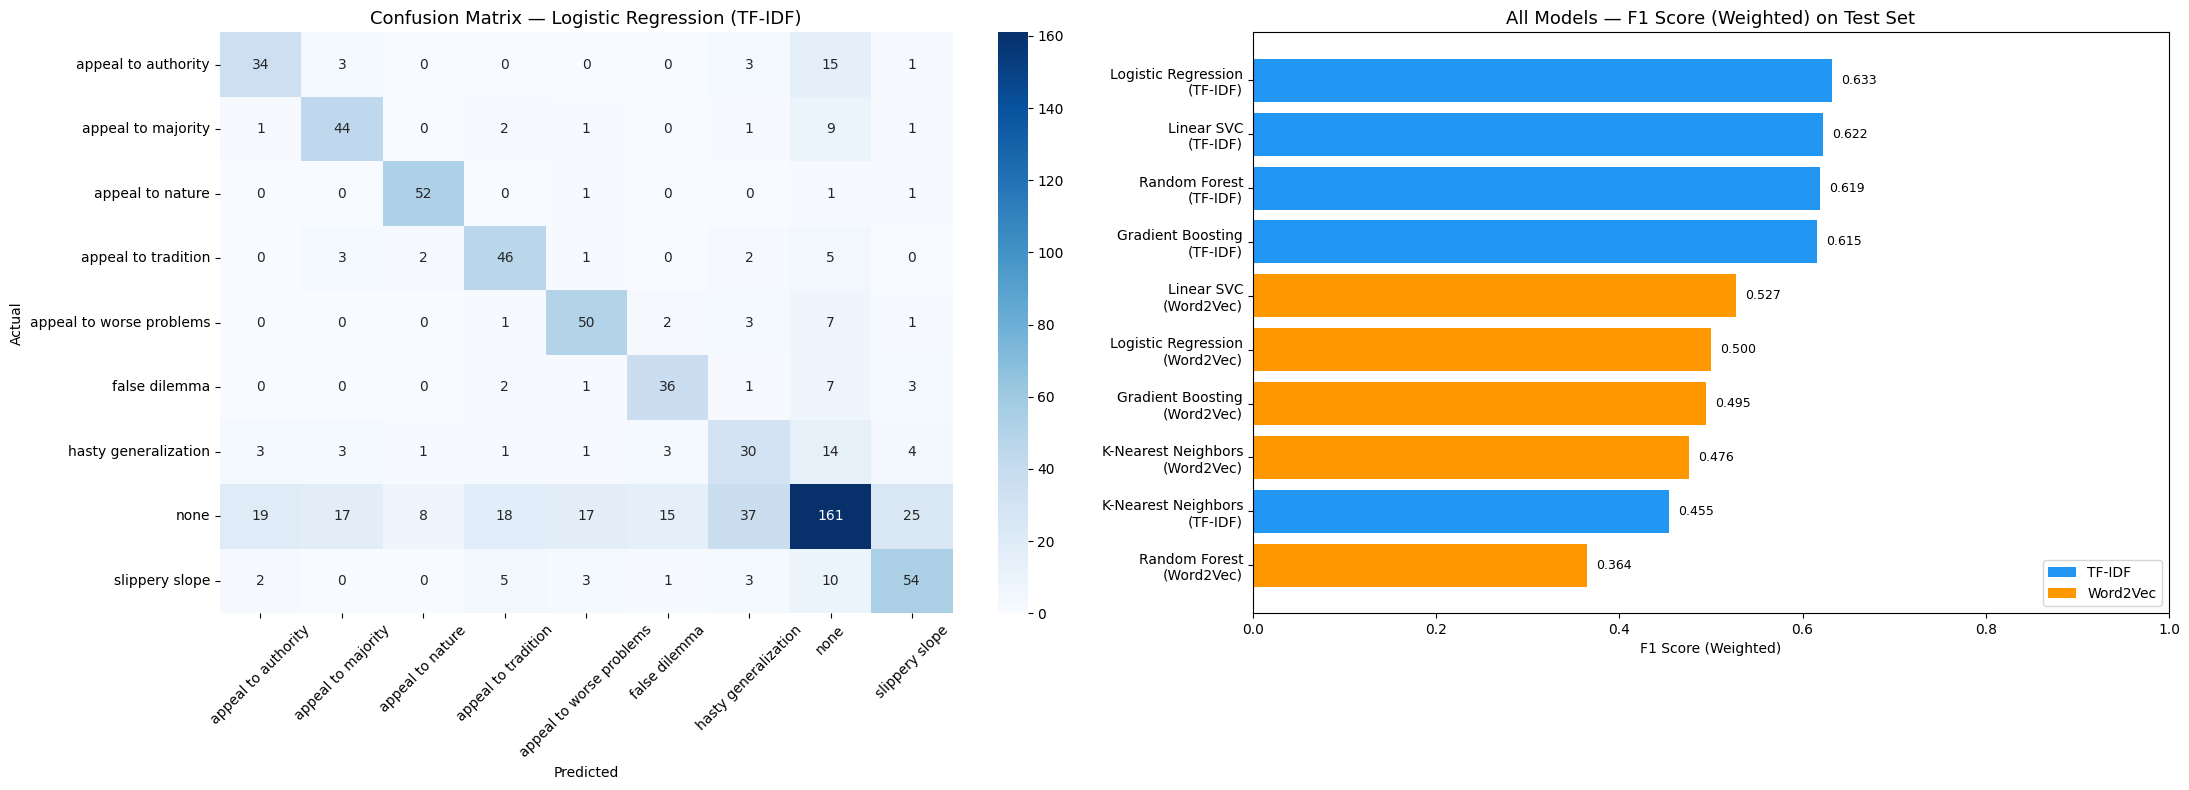

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# --- 1. Confusion Matrix (Best Model) ---
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix — {best_name} ({best_features})', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# --- 2. Model Comparison Bar Chart —--
plot_df = results_df.copy()
plot_df = plot_df.sort_values('F1 (weighted)', ascending=True)
plot_df['Label'] = plot_df['Model'] + '\n(' + plot_df['Features'] + ')'

colors = ['#2196F3' if f == 'TF-IDF' else '#FF9800' for f in plot_df['Features']]
axes[1].barh(plot_df['Label'], plot_df['F1 (weighted)'], color=colors)
axes[1].set_title('All Models — F1 Score (Weighted) on Test Set', fontsize=13)
axes[1].set_xlabel('F1 Score (Weighted)')
axes[1].set_xlim(0, 1)

# Add value labels
for i, (val, label) in enumerate(zip(plot_df['F1 (weighted)'], plot_df['Label'])):
    axes[1].text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='TF-IDF'),
                   Patch(facecolor='#FF9800', label='Word2Vec')]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

### Per-Class F1-Score Breakdown

Menampilkan F1-Score per jenis fallacy untuk mengidentifikasi kelas mana yang paling sulit dideteksi.

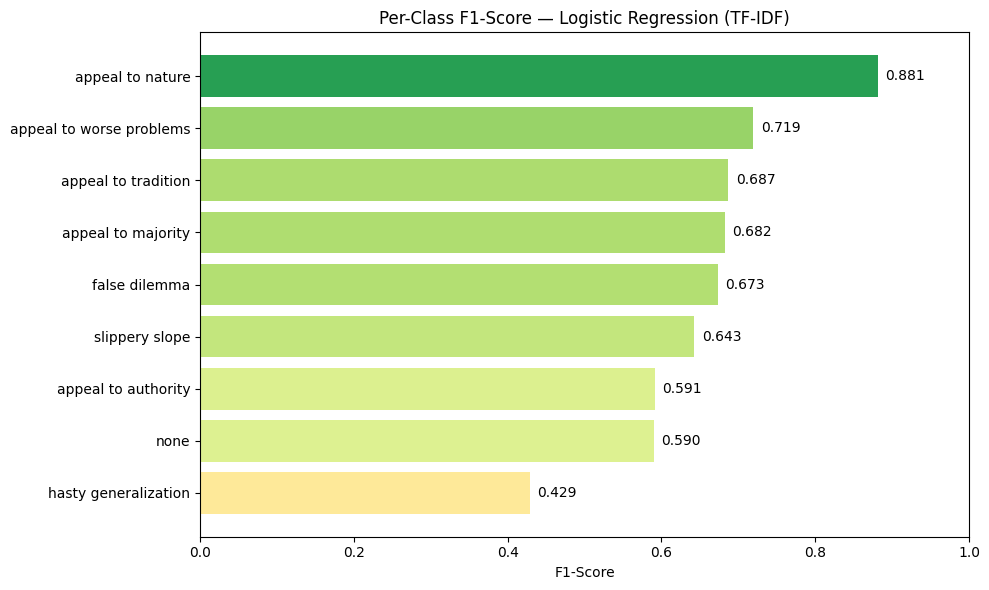


--- Per-Class Metrics (Logistic Regression, TF-IDF) ---


,Precision,Recall,F1-Score,Support
Fallacy Type,,,,
appeal to nature,0.8254,0.9455,0.8814,55
appeal to worse problems,0.6667,0.7812,0.7194,64
appeal to tradition,0.6133,0.7797,0.6866,59
appeal to majority,0.6286,0.7458,0.6822,59
false dilemma,0.6316,0.7200,0.6729,50
slippery slope,0.6000,0.6923,0.6429,78
appeal to authority,0.5763,0.6071,0.5913,56
none,0.7031,0.5079,0.5897,317
hasty generalization,0.3750,0.5000,0.4286,60


In [15]:
# Per-class F1 breakdown for best model
p_cls, r_cls, f1_cls, sup_cls = precision_recall_fscore_support(
    y_test, y_pred_best, labels=range(len(label_encoder.classes_))
)

class_df = pd.DataFrame({
    'Fallacy Type': label_encoder.classes_,
    'Precision': p_cls,
    'Recall': r_cls,
    'F1-Score': f1_cls,
    'Support': sup_cls.astype(int)
}).sort_values('F1-Score', ascending=True)

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(class_df['F1-Score'].values)
bars = ax.barh(class_df['Fallacy Type'], class_df['F1-Score'], color=colors)
ax.set_xlabel('F1-Score')
ax.set_title(f'Per-Class F1-Score — {best_name} ({best_features})')
ax.set_xlim(0, 1)

for bar, val in zip(bars, class_df['F1-Score'].values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# --- Table ---
print(f"\n--- Per-Class Metrics ({best_name}, {best_features}) ---")
class_df_display = class_df.sort_values('F1-Score', ascending=False).set_index('Fallacy Type')
class_df_display.style.format({
    'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1-Score': '{:.4f}'
}).background_gradient(subset=['F1-Score'], cmap='RdYlGn')

## 12. Predict New Input

Fungsi untuk memprediksi jenis logical fallacy dari sebuah teks baru menggunakan model terbaik.

In [23]:
def predict_fallacy(text, model=None, features=None, top_n=3):
    """
    Prediksi jenis logical fallacy dari sebuah teks komentar.
    
    Parameters:
        text (str): Teks komentar yang akan diprediksi
        model: Model sklearn (default: best model dari evaluasi)
        features (str): 'TF-IDF' atau 'Word2Vec' (default: sesuai best model)
        top_n (int): Jumlah prediksi teratas yang ditampilkan
    
    Returns:
        str: Label fallacy yang diprediksi
    """
    if model is None:
        model = best_model
        features = best_features
    
    # Preprocessing pipeline (same as training)
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    lemmatized = lemmatize_tokens(tokens)
    processed = ' '.join(lemmatized)
    
    # Feature extraction
    if 'tfidf' in features.lower() or 'tf-idf' in features.lower():
        X = tfidf_vectorizer.transform([processed])
    else:
        vec = document_vector(lemmatized, w2v_model)
        X = vec.reshape(1, -1)
    
    # Prediction
    prediction = model.predict(X)[0]
    predicted_label = label_encoder.inverse_transform([prediction])[0]
    
    # Display results
    print(f"  INPUT: \"{text[:100]}{'...' if len(text) > 100 else ''}\"")
    print(f"  Preprocessed : {processed[:80]}{'...' if len(processed) > 80 else ''}")
    print(f"  Token count  : {len(lemmatized)}")
    print(f"\n Predicted Fallacy: {predicted_label.upper()}")
    
    # Show confidence scores if available
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)[0]
        top_indices = np.argsort(proba)[::-1][:top_n]
        print(f"\n  Top-{top_n} predictions:")
        for idx in top_indices:
            label = label_encoder.inverse_transform([idx])[0]
            bar = '█' * int(proba[idx] * 30)
            print(f"    {label:30s} {proba[idx]:.4f} ({proba[idx]*100:.1f}%) {bar}")
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(X)[0]
        top_indices = np.argsort(scores)[::-1][:top_n]
        print(f"\n  Top-{top_n} predictions (decision score):")
        for idx in top_indices:
            label = label_encoder.inverse_transform([idx])[0]
            print(f"    {label:30s} score: {scores[idx]:.4f}")
    
    return predicted_label

print("✓ Fungsi predict_fallacy() siap digunakan.")

✓ Fungsi predict_fallacy() siap digunakan.


In [24]:
# Test with example inputs covering all fallacy types
test_texts = [
    # Slippery slope
    "If we allow students to use AI for homework, next they'll use it for exams, then for job interviews, and eventually nobody will learn anything anymore.",
    # Appeal to authority
    "Dr. Smith, a renowned professor at Harvard, says this policy is the best approach, so it must be correct.",
    # Appeal to majority
    "Most people agree that this is the right thing to do, so it must be true.",
    # Appeal to tradition
    "We've always done it this way for generations, so there's no reason to change now.",
    # Appeal to nature
    "This product is made from all-natural ingredients, so it must be healthy and safe for you.",
    # False dilemma
    "You're either with us or against us. There's no middle ground on this issue.",
    # Hasty generalization
    "I met two rude people from that city, so everyone there must be rude and unfriendly.",
    # Appeal to worse problems
    "Why worry about climate change when there are people dying of hunger every day?",
    # None (neutral argument)
    "I think we should carefully reform education policy based on evidence and data from recent peer-reviewed studies.",
]

print("LOGICAL FALLACY PREDICTIONS (Best Model)")
for text in test_texts:
    result = predict_fallacy(text)
    print()

LOGICAL FALLACY PREDICTIONS (Best Model)
  INPUT: "If we allow students to use AI for homework, next they'll use it for exams, then for job interviews,..."
  Preprocessed : allow student use homework next theyll use exam job interview eventually nobody ...
  Token count  : 15

 Predicted Fallacy: SLIPPERY SLOPE

  Top-3 predictions:
    slippery slope                 0.6855 (68.5%) ████████████████████
    none                           0.0763 (7.6%) ██
    hasty generalization           0.0509 (5.1%) █

  INPUT: "Dr. Smith, a renowned professor at Harvard, says this policy is the best approach, so it must be cor..."
  Preprocessed : smith renowned professor harvard say policy best approach must correct
  Token count  : 10

 Predicted Fallacy: APPEAL TO AUTHORITY

  Top-3 predictions:
    appeal to authority            0.6995 (70.0%) ████████████████████
    appeal to tradition            0.0693 (6.9%) ██
    none                           0.0555 (5.5%) █

  INPUT: "Most people agree t

### Try Manual input

Ubah variabel `my_text` di bawah untuk menguji model dengan komentar kita sendiri.

In [25]:
my_text = "Everyone knows the earth is flat, millions of people believe it, so it must be true."

predict_fallacy(my_text)

  INPUT: "Everyone knows the earth is flat, millions of people believe it, so it must be true."
  Preprocessed : everyone know earth flat million people believe must true
  Token count  : 9

 Predicted Fallacy: APPEAL TO MAJORITY

  Top-3 predictions:
    appeal to majority             0.8207 (82.1%) ████████████████████████
    hasty generalization           0.0453 (4.5%) █
    appeal to authority            0.0402 (4.0%) █


'appeal to majority'